# 线性系统的数值计算方法

本文档关注线性系统，比较LQR的两种数值计算方法。我们考虑线性系统：
\begin{align*}
    \dot{x}(t)=Ax(t)+Bu(t),\qquad x(0)=x_0,
\end{align*}
其中，$x(t)\in\mathbb{R}^n$、$u(t)\in\mathbb{R}^m$、$A$与$B$分别为矩阵。
给定初始状态$x_0$的条件下，我们寻找控制函数 $u(t)$，最小化性能指标
\begin{align*}
J(u)=\int_0^T \bigl(x(t)^\top Qx(t)+u(t)^\top Ru(t)\bigr)\,d t + x(T)^\top F x(T)
\end{align*}
其中，$Q\succeq 0$、$R\succ 0$、$F\succeq 0$ 为权重矩阵。

我们先设定一个简单的二维线性系统，其矩阵参数取为
\begin{align*}
&A = \begin{bmatrix} -0.7 & 0.5 \\ 1 & -1.5 \end{bmatrix},
&& B = \begin{bmatrix} 1 \\ 0.5 \end{bmatrix},
&& Q = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
&& R = \begin{bmatrix} 1 \end{bmatrix},\\
& F = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
&& x_0 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}.
&& T = 10
\end{align*}
后续两种数值方法都基于这一组参数进行求解与比较。

In [1]:
# Required packages for this notebook: torch, matplotlib
# If needed, install them with: pip install torch matplotlib

import time
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})

In [2]:
T = 10
dt = 0.01
x0 = torch.tensor([[1.], [1.]])
A = torch.tensor([[-0.7, 0.5], [1., -1.5]])
B = torch.tensor([[1.], [0.5]])
Q = torch.eye(2)
R = torch.eye(1)
F = torch.tensor([[1., 0.], [0., 1.]])


def simulate_system(A, B, Q, R, F, x0, u, T, dt):
    """Simulate the continuous-time linear system with forward Euler."""
    # u is expected to be of shape (num_steps, control_dim)
    num_steps = int(T / dt)
    state_dim = x0.shape[0]
    control_dim = B.shape[1]
    if u.shape[0] != num_steps or u.shape[1] != control_dim:
        raise ValueError(f"Control input u must have shape ({num_steps}, {control_dim})")

    time_grid = torch.linspace(0.0, num_steps * dt, num_steps + 1)
    x = torch.zeros(num_steps + 1, state_dim, dtype=x0.dtype)
    x[0] = x0.squeeze(-1)
    pre_x = x0
    J = 0

    # Simulate the system forward in time using forward Euler integration
    for k in range(num_steps):
        control = u[k].unsqueeze(-1)
        J = J + (pre_x.T @ Q @ pre_x + control.T @ R @ control) * dt
        state_derivative = A @ pre_x + B @ control
        pre_x = pre_x + dt * state_derivative
        x[k + 1] = pre_x.squeeze(-1)
    
    J = J + pre_x.T @ F @ pre_x # Add terminal cost

    return time_grid, x, J

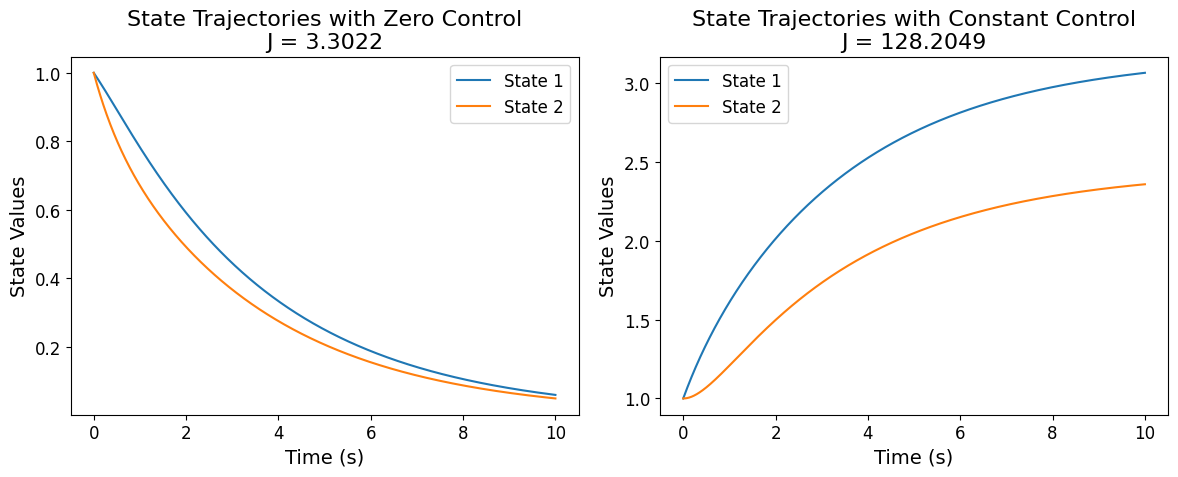

In [3]:
# plottting the simulation results

u_zero = torch.zeros(int(T / dt), 1)
time_grid_zero, x_zero, J_zero = simulate_system(A, B, Q, R, F, x0, u_zero, T, dt)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_grid_zero, x_zero[:, 0], label='State 1')
plt.plot(time_grid_zero, x_zero[:, 1], label='State 2')
plt.title(f'State Trajectories with Zero Control\nJ = {J_zero.item():.4f}')
plt.xlabel('Time (s)')
plt.ylabel('State Values')
plt.legend()

u_const = torch.ones(int(T / dt), 1)
time_grid_const, x_const, J_const = simulate_system(A, B, Q, R, F, x0, u_const, T, dt)

plt.subplot(1, 2, 2)
plt.plot(time_grid_const, x_const[:, 0], label='State 1')
plt.plot(time_grid_const, x_const[:, 1], label='State 2')
plt.title(f'State Trajectories with Constant Control\nJ = {J_const.item():.4f}')
plt.xlabel('Time (s)')
plt.ylabel('State Values')
plt.legend()

plt.tight_layout()
plt.show()

# print(f'Zero control cost J = {J_zero.item():.4f}')
# print(f'Constant control cost J = {J_const.item():.4f}')

## 1. 直接计算方法

一种最直接的思路是：先对上述连续问题进行离散化，再把每个离散时刻的控制输入都看作待优化变量，从而直接对离散化后的目标函数进行数值优化。

In [4]:
num_steps = int(T / dt)
control_dim = 1
num_iters = 100
lr = 7

# 初始给出一个全零的控制输入
u = torch.zeros(num_steps, control_dim, dtype=x0.dtype, requires_grad=True)
loss_history = []

start_time = time.perf_counter()

# 开始梯度下降
for iteration in range(num_iters):
    time_grid, x, J = simulate_system(A, B, Q, R, F, x0, u, T, dt)
    loss = J.squeeze()

    loss.backward()

    with torch.no_grad():
        grad_norm = torch.norm(u.grad).item()
        u -= lr * u.grad
        u.grad.zero_()

    loss_history.append(loss.item())

    if iteration % 10 == 0:
        print(f"iter={iteration:4d}, J={loss.item():.6f}, grad_norm={grad_norm:.6f}")

    # if grad_norm < 1e-6:
    #     break

elapsed_time = time.perf_counter() - start_time

u_opt = u.detach()
time_grid_opt, x_opt, J_opt = simulate_system(A, B, Q, R, F, x0, u_opt, T, dt)
control_time = time_grid_opt[:-1]


print("-" * 50) # 分割线
print(f"final iterations = {iteration + 1}")
print(f"final cost J = {J_opt.item():.6f}")
print(f"final gradient norm = {grad_norm:.6f}")
print(f"elapsed time = {elapsed_time:.6f} s")

iter=   0, J=3.302151, grad_norm=0.711818
iter=  10, J=1.347824, grad_norm=0.011987
iter=  20, J=1.345270, grad_norm=0.001605
iter=  30, J=1.345217, grad_norm=0.000265
iter=  40, J=1.345217, grad_norm=0.000048
iter=  50, J=1.345216, grad_norm=0.000009
iter=  60, J=1.345216, grad_norm=0.000002
iter=  70, J=1.345216, grad_norm=0.000000
iter=  80, J=1.345216, grad_norm=0.000000
iter=  90, J=1.345217, grad_norm=0.000000
--------------------------------------------------
final iterations = 100
final cost J = 1.345217
final gradient norm = 0.000000
elapsed time = 16.371394 s


final cost J = 1.345217
elapsed time = 16.371394 s


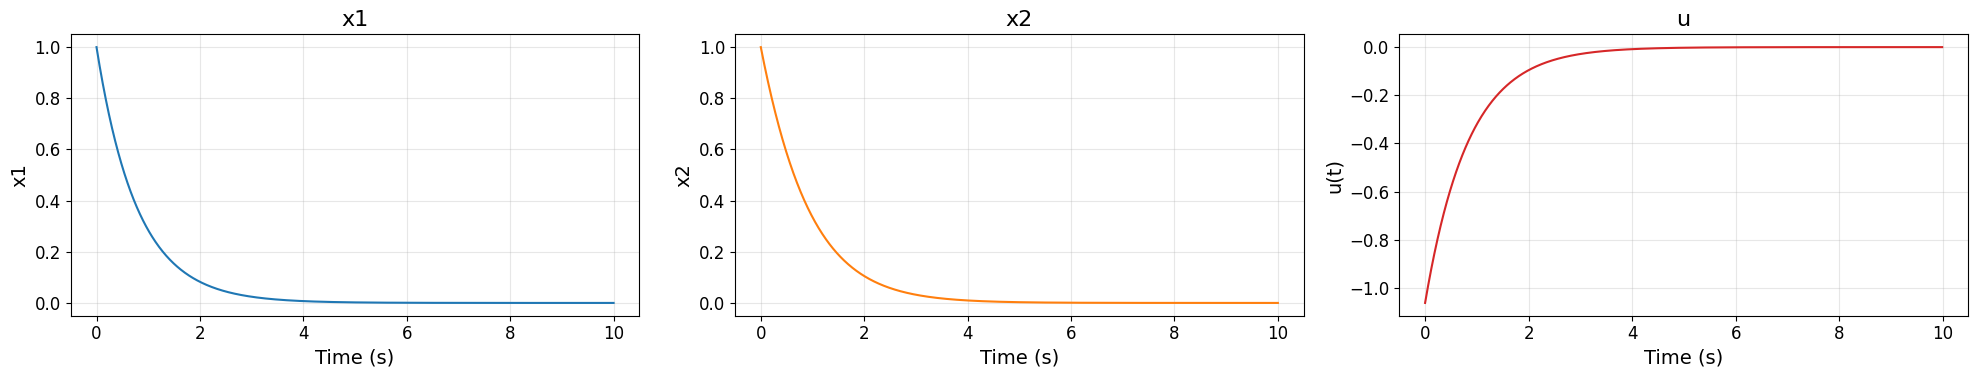

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

axes[0].plot(time_grid_opt, x_opt[:, 0], color="tab:blue")
axes[0].set_title("x1")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x1")
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_grid_opt, x_opt[:, 1], color="tab:orange")
axes[1].set_title("x2")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("x2")
axes[1].grid(True, alpha=0.3)

axes[2].plot(control_time, u_opt[:, 0], color="tab:red")
axes[2].set_title("u")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("u(t)")
axes[2].grid(True, alpha=0.3)

print(f"final cost J = {J_opt.item():.6f}")
print(f"elapsed time = {elapsed_time:.6f} s")

plt.tight_layout()
plt.show()

## 2. 基于Ricatti方程的计算方法

二次最优控制器满足
\begin{align*}
    u^*(t)=-R^{-1}B^\top P(t)\, x(t)
\end{align*}
其中，矩阵$P(t)$是下述Riccati方程的解。
\begin{align*}
    -\dot{P}(t)=A^\top P(t)+P(t)A-P(t)BR^{-1}B^\top P(t)+Q,\qquad P(T)=F.
\end{align*}
Riccati方程本质上是一个终端约束的常微分方程。从而，我们只需对Ricatti方程进行数值求解，并代入$u^*$的表达式，即可求解该问题。



--------------------------------------------------
riccati final cost J = 1.345236
riccati elapsed time = 0.056711 s


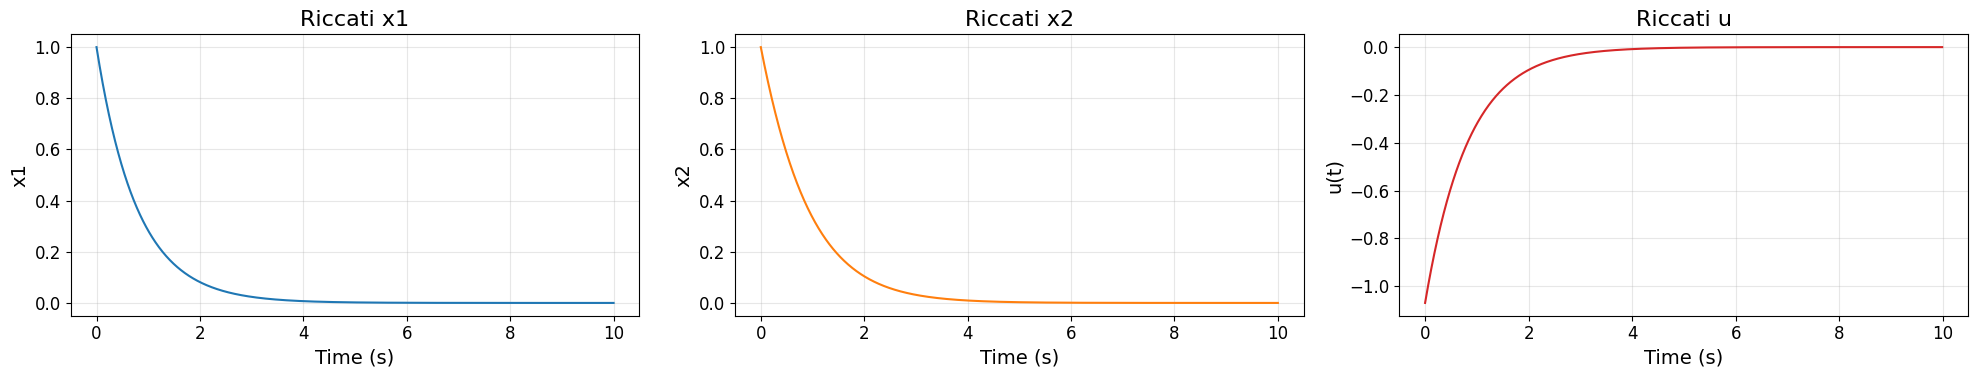

In [6]:
num_steps = int(T / dt)
state_dim = A.shape[0]
control_dim = B.shape[1]
R_inv = torch.linalg.inv(R)


start_time = time.perf_counter()


## 求解Riccati方程
P = torch.zeros(num_steps + 1, state_dim, state_dim, dtype=x0.dtype)
P[-1] = F
for k in range(num_steps - 1, -1, -1): # 从后往前迭代求解Riccati方程
    P_next = P[k + 1]
    riccati_rhs = A.T @ P_next + P_next @ A - P_next @ B @ R_inv @ B.T @ P_next + Q
    P[k] = P_next + dt * riccati_rhs


## 根据求解得到的P矩阵计算最优控制输入和状态轨迹
u_riccati = torch.zeros(num_steps, control_dim, dtype=x0.dtype)
x_riccati = torch.zeros(num_steps + 1, state_dim, dtype=x0.dtype)
x_riccati[0] = x0.squeeze(-1)
for k in range(num_steps):
    current_x = x_riccati[k].unsqueeze(-1)
    K_k = R_inv @ B.T @ P[k]
    control = -K_k @ current_x
    u_riccati[k] = control.squeeze(-1)
    state_derivative = A @ current_x + B @ control
    x_riccati[k + 1] = (current_x + dt * state_derivative).squeeze(-1)



# 结果输出
elapsed_time_total = time.perf_counter() - start_time

time_grid_riccati, _, J_riccati = simulate_system(A, B, Q, R, F, x0, u_riccati, T, dt)
control_time_riccati = time_grid_riccati[:-1]

print("-" * 50)
print(f"riccati final cost J = {J_riccati.item():.6f}")
print(f"riccati elapsed time = {elapsed_time_total:.6f} s")

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

axes[0].plot(time_grid_riccati, x_riccati[:, 0], color="tab:blue")
axes[0].set_title("Riccati x1")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x1")
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_grid_riccati, x_riccati[:, 1], color="tab:orange")
axes[1].set_title("Riccati x2")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("x2")
axes[1].grid(True, alpha=0.3)

axes[2].plot(control_time_riccati, u_riccati[:, 0], color="tab:red")
axes[2].set_title("Riccati u")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("u(t)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.比较结果

直接方法：在所选取的参数下，大约20次迭代能达到较优的结果，总耗时约3秒。

基于Ricatti方程的方法：只需要0.05秒。

获得的最优值略有差距，主要归咎于离散带来的误差。

具体结果比较如下：

Direct method:
  cost J = 1.345217
  elapsed time = 3.274279 s
Riccati-based method:
  cost J = 1.345236
  elapsed time = 0.056711 s
  speedup = 57.74x


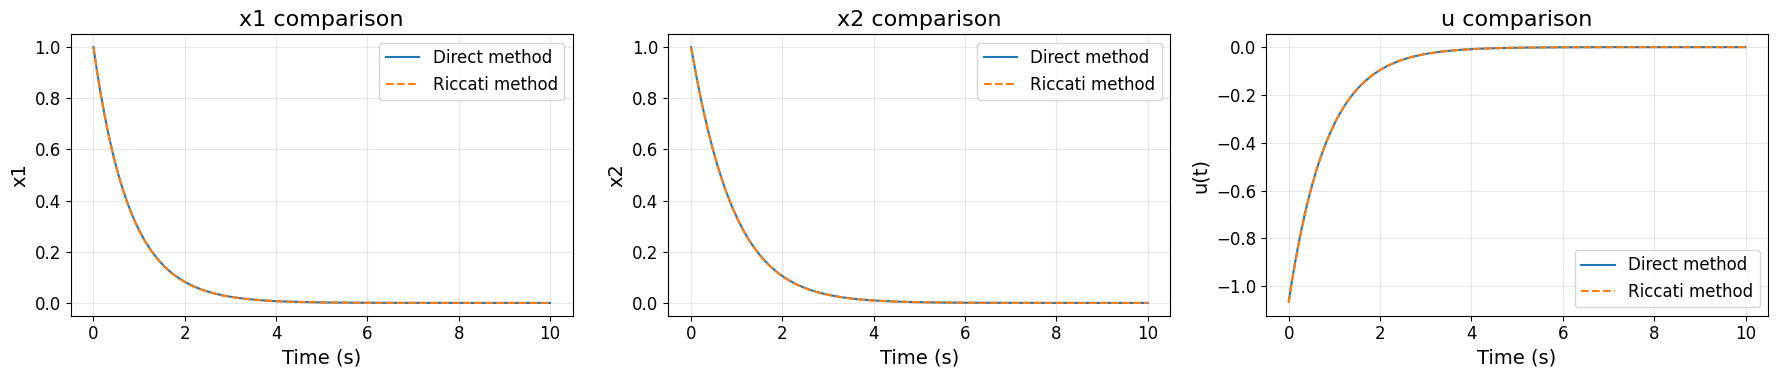

In [7]:
# 数值比较
speedup = elapsed_time / 5 / elapsed_time_total

print("Direct method:")
print(f"  cost J = {J_opt.item():.6f}")
print(f"  elapsed time = {elapsed_time/5:.6f} s")

print("Riccati-based method:")
print(f"  cost J = {J_riccati.item():.6f}")
print(f"  elapsed time = {elapsed_time_total:.6f} s")
print(f"  speedup = {speedup:.2f}x")

# 轨迹比较
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(time_grid_opt, x_opt[:, 0], label="Direct method", color="tab:blue")
axes[0].plot(time_grid_riccati, x_riccati[:, 0], label="Riccati method", color="tab:orange", linestyle="--")
axes[0].set_title("x1 comparison")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x1")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_grid_opt, x_opt[:, 1], label="Direct method", color="tab:blue")
axes[1].plot(time_grid_riccati, x_riccati[:, 1], label="Riccati method", color="tab:orange", linestyle="--")
axes[1].set_title("x2 comparison")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("x2")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(control_time, u_opt[:, 0], label="Direct method", color="tab:blue")
axes[2].plot(control_time_riccati, u_riccati[:, 0], label="Riccati method", color="tab:orange", linestyle="--")
axes[2].set_title("u comparison")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("u(t)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()